In [1]:
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)


In [ ]:
from kf_forecasting.models.dispred import (
    DistPredANNRegressor,
    component_correlation_summary,
    component_std_summary,
    discrete_crps_from_samples,
    distpred_eq13_loss,
    picp_from_interval,
    qice_from_samples,
    rolling_std_correlation_summary,
    simulate_m1_m9_additive_data,
)


## Kalman 分解與相關性工具

定義高低兩個 component 相關性摘要、Kalman filter，以及利用 Kalman filter 將觀測序列拆成線性與非線性部分的函式。

In [ ]:
def kalman_filter(observations, process_variance=0.5, measurement_variance=10.0, initial_error=1.0):
    initial_estimate = float(observations[0])
    estimated_state = initial_estimate
    estimate_error = float(initial_error)
    estimated_states = []

    for measurement in observations:
        predicted_state = estimated_state
        predicted_error = estimate_error + process_variance

        kalman_gain = predicted_error / (predicted_error + measurement_variance)
        estimated_state = predicted_state + kalman_gain * (measurement - predicted_state)
        estimate_error = (1.0 - kalman_gain) * predicted_error
        estimated_states.append(estimated_state)

    return np.array(estimated_states, dtype=float)


def decompose_with_simple_kf(series, process_variance=0.5, measurement_variance=10.0):
    estimated_low = kalman_filter(
        series,
        process_variance=process_variance,
        measurement_variance=measurement_variance,
        initial_error=1.0,
    )
    estimated_high = np.array(series, dtype=float) - estimated_low
    return estimated_low, estimated_high


## Joint DistPred 模型與訓練工具

這一段定義 joint window 建立方式、MLP 模型、loss function，以及 joint DistPred 的訓練與遞迴預測流程。

In [3]:
def find_arima_order(series, max_p=4, max_q=4):
    best_bic = np.inf
    best_order = (1, 0, 0)
    series = np.asarray(series, dtype=float)

    for p in range(max_p + 1):
        for q in range(max_q + 1):
            if p == 0 and q == 0:
                continue
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    fitted = ARIMA(series, order=(p, 0, q)).fit()
                if fitted.bic < best_bic:
                    best_bic = fitted.bic
                    best_order = (p, 0, q)
            except Exception:
                continue

    return best_order


def rolling_one_step_arima_forecast(train_series, horizon, ensemble_size, future_reference=None, order=None):
    history = np.asarray(train_series, dtype=float).copy()
    candidate_orders = []
    if order is not None:
        candidate_orders.append(order)
    else:
        candidate_orders.append(find_arima_order(history))
    for fallback_order in [(1, 0, 0), (0, 0, 1), (0, 0, 0)]:
        if fallback_order not in candidate_orders:
            candidate_orders.append(fallback_order)

    selected_order = candidate_orders[0]
    forecasts = []
    samples = np.zeros((ensemble_size, horizon), dtype=float)

    for step_idx in range(horizon):
        fitted = None
        used_order = None
        last_error = None
        for try_order in candidate_orders:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    fitted = ARIMA(history, order=try_order).fit()
                used_order = try_order
                break
            except Exception as exc:
                last_error = exc
                continue
        if fitted is None:
            raise last_error

        selected_order = used_order
        forecast_obj = fitted.get_forecast(1)
        mean_value = float(np.asarray(forecast_obj.predicted_mean).reshape(-1)[0])
        try:
            conf_int = np.asarray(forecast_obj.conf_int())
            lower = float(conf_int.reshape(-1, 2)[0, 0])
            upper = float(conf_int.reshape(-1, 2)[0, 1])
            sigma = max((upper - lower) / (2.0 * 1.96), 1e-6)
        except Exception:
            resid = np.asarray(fitted.resid, dtype=float)
            sigma = float(np.std(resid, ddof=1)) if len(resid) > 1 else 1e-3
            sigma = max(sigma, 1e-6)

        forecasts.append(mean_value)
        samples[:, step_idx] = np.random.normal(mean_value, sigma, size=ensemble_size)

        if future_reference is None:
            history = np.append(history, mean_value)
        else:
            history = np.append(history, float(future_reference[step_idx]))

    return np.asarray(forecasts, dtype=float), samples, selected_order


def fit_low_arima_residuals(low_series, order):
    low_series = np.asarray(low_series, dtype=float)
    if low_series.size == 0:
        return np.asarray([], dtype=float)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fitted = ARIMA(low_series, order=order).fit()
        residuals = np.asarray(fitted.resid, dtype=float)
    except Exception:
        residuals = low_series - np.mean(low_series)

    if residuals.shape[0] != low_series.shape[0]:
        padded = np.zeros_like(low_series, dtype=float)
        padded[-len(residuals):] = residuals
        residuals = padded
    return residuals


def rolling_low_arima_residuals(low_history, future_low_reference, order):
    low_history = np.asarray(low_history, dtype=float)
    future_low_reference = np.asarray(future_low_reference, dtype=float)
    history = low_history.copy()
    residuals = []

    for step_idx in range(len(future_low_reference)):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fitted = ARIMA(history, order=order).fit()
            forecast_obj = fitted.get_forecast(1)
            mean_value = float(np.asarray(forecast_obj.predicted_mean).reshape(-1)[0])
        except Exception:
            mean_value = float(history[-1]) if history.size else 0.0

        actual_value = float(future_low_reference[step_idx])
        residuals.append(actual_value - mean_value)
        history = np.append(history, actual_value)

    return np.asarray(residuals, dtype=float)


def create_high_windows(high_series, low_series, original_series, window_size, low_arima_residuals=None):
    high_series = np.asarray(high_series, dtype=float)
    low_series = np.asarray(low_series, dtype=float)
    original_series = np.asarray(original_series, dtype=float)

    if not (len(high_series) == len(low_series) == len(original_series)):
        raise ValueError("high_series, low_series, and original_series must have the same length.")
    if low_arima_residuals is None:
        low_arima_residuals = np.zeros(len(high_series), dtype=float)
    low_arima_residuals = np.asarray(low_arima_residuals, dtype=float)
    if len(low_arima_residuals) != len(high_series):
        raise ValueError("low_arima_residuals must have the same length as high_series.")

    features = []
    targets = []
    for idx in range(window_size, len(high_series)):
        high_window = high_series[idx - window_size:idx]
        low_window = low_series[idx - window_size:idx]
        original_window = original_series[idx - window_size:idx]
        residual_window = low_arima_residuals[idx - window_size:idx]
        feature_window = np.concatenate([high_window, low_window, original_window, residual_window]).astype(float)
        features.append(feature_window)
        targets.append(float(high_series[idx]))
    return np.asarray(features, dtype=float), np.asarray(targets, dtype=float)












def fit_high_ann_distpred_component(
    high_train,
    low_train,
    original_train,
    future_high_reference,
    future_low_reference,
    future_original_reference,
    window_size,
    ensemble_size=50,
    epochs=250,
    learning_rate=1e-3,
    hidden_dim_1=10,
    hidden_dim_2=10,
    low_arima_order=None,
):
    high_train = np.asarray(high_train, dtype=float)
    low_train = np.asarray(low_train, dtype=float)
    original_train = np.asarray(original_train, dtype=float)

    if future_high_reference is None:
        future_high_reference = np.repeat(high_train[-1], 1)
    if future_low_reference is None:
        future_low_reference = np.repeat(low_train[-1], len(np.asarray(future_high_reference, dtype=float)))
    if future_original_reference is None:
        future_original_reference = np.repeat(original_train[-1], len(np.asarray(future_high_reference, dtype=float)))

    future_high_reference = np.asarray(future_high_reference, dtype=float)
    future_low_reference = np.asarray(future_low_reference, dtype=float)
    future_original_reference = np.asarray(future_original_reference, dtype=float)

    if len(high_train) <= window_size:
        raise ValueError("Not enough high-frequency samples for ANN windows.")

    if low_arima_order is None:
        low_arima_order = find_arima_order(low_train)
    low_train_residuals = fit_low_arima_residuals(low_train, low_arima_order)

    X_train, y_train = create_high_windows(
        high_train,
        low_train,
        original_train,
        window_size,
        low_arima_residuals=low_train_residuals,
    )
    if len(X_train) == 0:
        raise ValueError("No valid high-frequency training windows were created.")

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(X_train)
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel().astype(np.float32)

    x_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

    input_dim = X_train.shape[1]
    model = DistPredANNRegressor(
        input_dim,
        ensemble_size,
        hidden_dim_1=hidden_dim_1,
        hidden_dim_2=hidden_dim_2,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    batch_size = min(32, len(X_train))
    loss_history = []

    model.train()
    for _ in range(epochs):
        perm = torch.randperm(len(x_tensor))
        batch_losses = []
        for start in range(0, len(x_tensor), batch_size):
            idx = perm[start:start + batch_size]
            xb = x_tensor[idx]
            yb = y_tensor[idx]

            optimizer.zero_grad()
            pred_ensemble = model(xb)
            loss = distpred_eq13_loss(pred_ensemble, yb)
            loss.backward()
            optimizer.step()

            batch_losses.append(float(loss.item()))
        loss_history.append(float(np.mean(batch_losses)))

    combined_high = np.concatenate([high_train[-window_size:], future_high_reference])
    combined_low = np.concatenate([low_train[-window_size:], future_low_reference])
    combined_original = np.concatenate([original_train[-window_size:], future_original_reference])
    future_low_residuals = rolling_low_arima_residuals(
        low_train,
        future_low_reference,
        low_arima_order,
    )
    combined_residuals = np.concatenate([low_train_residuals[-window_size:], future_low_residuals])

    testX, _ = create_high_windows(
        combined_high,
        combined_low,
        combined_original,
        window_size,
        low_arima_residuals=combined_residuals,
    )
    testX_scaled = x_scaler.transform(testX)
    test_tensor = torch.tensor(testX_scaled, dtype=torch.float32)

    with torch.no_grad():
        pred_scaled = model(test_tensor).cpu().numpy()

    pred = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(pred_scaled.shape)

    lower_q, upper_q = np.quantile(high_train, [0.01, 0.99])
    iqr = np.subtract(*np.quantile(high_train, [0.75, 0.25]))
    margin = max(0.5 * iqr, 0.25)
    clip_bounds = (float(lower_q - margin), float(upper_q + margin))

    high_samples = np.clip(pred.T, clip_bounds[0], clip_bounds[1])
    high_forecast = np.mean(high_samples, axis=0)

    return high_forecast, high_samples, {
        "window_size": window_size,
        "input_dim": input_dim,
        "ensemble_size": ensemble_size,
        "hidden_dim_1": hidden_dim_1,
        "hidden_dim_2": hidden_dim_2,
        "loss_history": loss_history,
        "final_loss": float(loss_history[-1]) if loss_history else np.nan,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "clip_bounds": clip_bounds,
        "model": model.eval(),
        "high_scale_mode": "component_level",
        "uses_low_arima_residual_window": True,
        "low_arima_order": low_arima_order,
    }


def hybrid_point_forecast(train_series, horizon, future_low_reference=None, future_high_reference=None, future_original_reference=None, window_size=15, ensemble_size=50, epochs=250, learning_rate=1e-3, hidden_dim_1=10, hidden_dim_2=10):
    if future_low_reference is None or future_high_reference is None:
        raise ValueError("paper26-style one-step rolling high ANN forecast requires future_low_reference and future_high_reference.")
    if future_original_reference is None:
        future_original_reference = future_low_reference + future_high_reference

    estimated_low, estimated_high = decompose_with_simple_kf(train_series)
    low_arima_order = find_arima_order(estimated_low)
    low_forecast, low_samples, _ = rolling_one_step_arima_forecast(
        estimated_low,
        horizon,
        ensemble_size=ensemble_size,
        future_reference=future_low_reference,
        order=low_arima_order,
    )
    high_forecast, high_samples, bundle = fit_high_ann_distpred_component(
        estimated_high,
        estimated_low,
        np.asarray(train_series, dtype=float),
        future_high_reference,
        future_low_reference,
        future_original_reference,
        window_size=window_size,
        ensemble_size=ensemble_size,
        epochs=epochs,
        learning_rate=learning_rate,
        hidden_dim_1=hidden_dim_1,
        hidden_dim_2=hidden_dim_2,
        low_arima_order=low_arima_order,
    )
    final_samples = low_samples + high_samples
    final_forecast = low_forecast + high_forecast

    return {
        "estimated_low": estimated_low,
        "estimated_high": estimated_high,
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "low_samples": low_samples,
        "high_samples": high_samples,
        "joint_bundle": bundle,
        "final_samples": final_samples,
        "final_forecast": final_forecast,
        "window_size": window_size,
        "hidden_dim_1": hidden_dim_1,
        "hidden_dim_2": hidden_dim_2,
        "low_arima_order": low_arima_order,
    }


def timed_hybrid_point_forecast(train_series, horizon, future_low_reference=None, future_high_reference=None, future_original_reference=None, window_size=15, ensemble_size=50, epochs=250, learning_rate=1e-3, hidden_dim_1=10, hidden_dim_2=10):
    if future_low_reference is None or future_high_reference is None:
        raise ValueError("paper26-style one-step rolling high ANN forecast requires future_low_reference and future_high_reference.")
    if future_original_reference is None:
        future_original_reference = future_low_reference + future_high_reference

    timing = {
        "kf_decomposition": 0.0,
        "arima_low_fit_forecast": 0.0,
        "distpred_high_fit_forecast": 0.0,
    }

    kf_start = time.perf_counter()
    estimated_low, estimated_high = decompose_with_simple_kf(train_series)
    timing["kf_decomposition"] += time.perf_counter() - kf_start

    arima_start = time.perf_counter()
    low_arima_order = find_arima_order(estimated_low)
    low_forecast, low_samples, _ = rolling_one_step_arima_forecast(
        estimated_low,
        horizon,
        ensemble_size=ensemble_size,
        future_reference=future_low_reference,
        order=low_arima_order,
    )
    timing["arima_low_fit_forecast"] += time.perf_counter() - arima_start

    distpred_start = time.perf_counter()
    high_forecast, high_samples, bundle = fit_high_ann_distpred_component(
        estimated_high,
        estimated_low,
        np.asarray(train_series, dtype=float),
        future_high_reference,
        future_low_reference,
        future_original_reference,
        window_size=window_size,
        ensemble_size=ensemble_size,
        epochs=epochs,
        learning_rate=learning_rate,
        hidden_dim_1=hidden_dim_1,
        hidden_dim_2=hidden_dim_2,
        low_arima_order=low_arima_order,
    )
    timing["distpred_high_fit_forecast"] += time.perf_counter() - distpred_start

    final_samples = low_samples + high_samples
    final_forecast = low_forecast + high_forecast

    return {
        "estimated_low": estimated_low,
        "estimated_high": estimated_high,
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "low_samples": low_samples,
        "high_samples": high_samples,
        "joint_bundle": bundle,
        "final_samples": final_samples,
        "final_forecast": final_forecast,
        "window_size": window_size,
        "hidden_dim_1": hidden_dim_1,
        "hidden_dim_2": hidden_dim_2,
        "low_arima_order": low_arima_order,
    }, timing


## 繪圖工具

這一段提供互動圖與 component 相關性圖的繪製函式，用來觀察線性與非線性部分之間的關係。

In [4]:
def plot_interaction(bundle, low_history, high_history, original_history=None, grid_points=41):
    window_size = bundle["window_size"]
    ensemble_size = bundle["ensemble_size"]
    low_history = np.asarray(low_history, dtype=float)
    high_history = np.asarray(high_history, dtype=float)
    if original_history is None:
        original_history = low_history + high_history
    original_history = np.asarray(original_history, dtype=float)

    base_low = low_history[-window_size:]
    base_high = high_history[-window_size:]
    base_original = original_history[-window_size:]
    low_arima_order = bundle.get("low_arima_order")
    if low_arima_order is None:
        base_residuals = np.zeros_like(low_history, dtype=float)
    else:
        base_residuals = fit_low_arima_residuals(low_history, low_arima_order)
    base_residual_window = base_residuals[-window_size:]

    low_min = float(np.quantile(low_history, 0.01))
    low_max = float(np.quantile(low_history, 0.99))
    high_min, high_max = bundle["clip_bounds"]
    low_grid = np.linspace(low_min, low_max, grid_points)
    high_grid = np.linspace(high_min, high_max, grid_points)

    mean_surface = np.zeros((grid_points, grid_points), dtype=float)
    width_surface = np.zeros((grid_points, grid_points), dtype=float)

    for i, low_val in enumerate(low_grid):
        for j, high_val in enumerate(high_grid):
            low_window = base_low.copy()
            high_window = base_high.copy()
            original_window = base_original.copy()
            low_window[-1] = low_val
            high_window[-1] = high_val
            original_window[-1] = low_val + high_val

            features = np.concatenate([high_window, low_window, original_window, base_residual_window]).reshape(1, -1)
            features = np.repeat(features, ensemble_size, axis=0)
            features_scaled = bundle["x_scaler"].transform(features)
            with torch.no_grad():
                pred_scaled = bundle["model"](torch.tensor(features_scaled, dtype=torch.float32)).cpu().numpy()

            high_samples = bundle["y_scaler"].inverse_transform(
                pred_scaled.reshape(-1, 1)
            ).reshape(pred_scaled.shape)
            high_samples = np.clip(high_samples, bundle["clip_bounds"][0], bundle["clip_bounds"][1])

            mean_surface[j, i] = np.mean(high_samples)
            width_surface[j, i] = np.quantile(high_samples, 0.975) - np.quantile(high_samples, 0.025)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    mesh0 = axes[0].imshow(
        mean_surface,
        origin="lower",
        aspect="auto",
        extent=[low_grid[0], low_grid[-1], high_grid[0], high_grid[-1]],
    )
    axes[0].set_title("ANN high mean")
    axes[0].set_xlabel("Current low window last value")
    axes[0].set_ylabel("Current high window last value")
    fig.colorbar(mesh0, ax=axes[0])

    mesh1 = axes[1].imshow(
        width_surface,
        origin="lower",
        aspect="auto",
        extent=[low_grid[0], low_grid[-1], high_grid[0], high_grid[-1]],
    )
    axes[1].set_title("ANN high 95% width")
    axes[1].set_xlabel("Current low window last value")
    axes[1].set_ylabel("Current high window last value")
    fig.colorbar(mesh1, ax=axes[1])

    plt.show()
    plt.close(fig)

def plot_component_correlation(true_low, true_high, estimated_low, estimated_high):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))

    true_corr = component_correlation_summary(true_low, true_high)
    estimated_corr = component_correlation_summary(estimated_low, estimated_high)

    axes[0, 0].plot(true_low, label="True linear", linewidth=1.5)
    axes[0, 0].plot(true_high, label="True nonlinear", linewidth=1.2)
    axes[0, 0].set_title(f"Generated components (corr={true_corr['pearson_corr']:.3f})")
    axes[0, 0].legend()

    axes[0, 1].scatter(true_low, true_high, s=12, alpha=0.7)
    axes[0, 1].set_title("Generated linear vs nonlinear")
    axes[0, 1].set_xlabel("True linear")
    axes[0, 1].set_ylabel("True nonlinear")

    axes[1, 0].plot(estimated_low, label="KF linear", linewidth=1.5)
    axes[1, 0].plot(estimated_high, label="KF nonlinear", linewidth=1.2)
    axes[1, 0].set_title(f"KF components (corr={estimated_corr['pearson_corr']:.3f})")
    axes[1, 0].legend()

    axes[1, 1].scatter(estimated_low, estimated_high, s=12, alpha=0.7, color="tab:orange")
    axes[1, 1].set_title("KF linear vs KF nonlinear")
    axes[1, 1].set_xlabel("KF linear")
    axes[1, 1].set_ylabel("KF nonlinear")

    fig.tight_layout()
    plt.show()
    plt.close(fig)



## 模擬資料生成與單次實驗函式

這一段定義文獻 giordano 模擬資料生成方式，並封裝單次實驗流程，包含資料生成、KF 分解、joint DistPred 預測與評估指標計算。

In [5]:


def normalize_hyperparams(params):
    normalized = dict(params)
    if "ensemble_size" in normalized:
        normalized["ensemble_size"] = int(round(float(normalized["ensemble_size"])))
    if "epochs" in normalized:
        normalized["epochs"] = int(round(float(normalized["epochs"])))
    if "window_size" in normalized:
        normalized["window_size"] = int(round(float(normalized["window_size"])))
    if "learning_rate" in normalized:
        normalized["learning_rate"] = float(normalized["learning_rate"])
    return normalized


def build_rolling_validation_splits(series, min_train_size=150, val_size=50, step_size=50):
    series = np.asarray(series, dtype=float)
    splits = []
    train_end = int(min_train_size)
    val_size = int(val_size)
    step_size = int(step_size)

    while train_end + val_size <= len(series):
        splits.append({
            "train_size": train_end,
            "horizon": val_size,
            "train_series": series[:train_end],
            "validation_series": series[train_end:train_end + val_size],
            "full_series": series[:train_end + val_size],
        })
        train_end += step_size

    return splits


def evaluate_high_ann_validation_split(fold_data, window_size, ensemble_size=50, epochs=250, learning_rate=1e-3):
    full_series = np.asarray(fold_data["full_series"], dtype=float)
    train_size = int(fold_data["train_size"])
    horizon = int(fold_data["horizon"])

    estimated_low_full, estimated_high_full = decompose_with_simple_kf(full_series)
    reference_low_val = estimated_low_full[train_size:train_size + horizon]
    reference_high_val = estimated_high_full[train_size:train_size + horizon]

    forecast_bundle, _ = timed_hybrid_point_forecast(
        full_series[:train_size],
        horizon,
        future_low_reference=reference_low_val,
        future_high_reference=reference_high_val,
        future_original_reference=full_series[train_size:train_size + horizon],
        window_size=window_size,
        ensemble_size=ensemble_size,
        epochs=epochs,
        learning_rate=learning_rate,
    )

    final_forecast = forecast_bundle["final_forecast"]
    final_samples = forecast_bundle["final_samples"]
    validation_series = full_series[train_size:train_size + horizon]
    interval_lower = np.quantile(final_samples, 0.025, axis=0)
    interval_upper = np.quantile(final_samples, 0.975, axis=0)

    rmse = float(np.sqrt(np.mean((final_forecast - validation_series) ** 2)))
    val_std = float(np.std(validation_series, ddof=1))
    normalized_rmse = rmse / max(val_std, 1e-8)
    picp_95 = picp_from_interval(interval_lower, interval_upper, validation_series)
    mean_interval_width = float(np.mean(interval_upper - interval_lower))

    return {
        "rmse": rmse,
        "normalized_rmse": normalized_rmse,
        "picp_95": picp_95,
        "mean_interval_width": mean_interval_width,
    }


def grid_search_high_ann_rolling_cv(
    train_series,
    param_grid,
    val_size=50,
    min_train_size=150,
    step_size=50,
    top_k=5,
):
    from itertools import product

    train_series = np.asarray(train_series, dtype=float)
    validation_sets = build_rolling_validation_splits(
        train_series,
        min_train_size=min_train_size,
        val_size=val_size,
        step_size=step_size,
    )
    if not validation_sets:
        raise ValueError("No rolling validation splits were created. Reduce min_train_size or val_size.")

    grid_keys = list(param_grid.keys())
    results = []

    for values in product(*[param_grid[key] for key in grid_keys]):
        params = normalize_hyperparams(dict(zip(grid_keys, values)))
        fold_metrics = []
        for fold_data in validation_sets:
            fold_metrics.append(
                evaluate_high_ann_validation_split(
                    fold_data,
                    **params,
                )
            )

        mean_rmse = float(np.mean([m["rmse"] for m in fold_metrics]))
        mean_nrmse = float(np.mean([m["normalized_rmse"] for m in fold_metrics]))
        mean_picp = float(np.mean([m["picp_95"] for m in fold_metrics]))
        mean_width = float(np.mean([m["mean_interval_width"] for m in fold_metrics]))
        coverage_gap = abs(mean_picp - 0.95)
        selection_score = 1.25 * mean_nrmse + 1.50 * coverage_gap + 0.001 * mean_width

        results.append({
            **params,
            "n_folds": len(fold_metrics),
            "mean_rmse": mean_rmse,
            "mean_normalized_rmse": mean_nrmse,
            "mean_picp_95": mean_picp,
            "mean_interval_width": mean_width,
            "selection_score": selection_score,
        })

    results = sorted(
        results,
        key=lambda row: (
            row["selection_score"],
            row["mean_normalized_rmse"],
            row["mean_rmse"],
        ),
    )
    best_params = normalize_hyperparams({key: results[0][key] for key in grid_keys})
    return validation_sets, results, best_params, results[:top_k]


def run_single_experiment(
    train_size=300,
    horizon=1,
    window_size=15,
    ensemble_size=50,
    epochs=250,
    learning_rate=1e-3,
    generated_data=None,
    validation_summary=None,
):
    timing_info = {
        "data_generation": 0.0,
        "point_forecast_fit": 0.0,
        "kf_decomposition": 0.0,
        "distpred_high_fit_forecast": 0.0,
    }

    n_steps = train_size + horizon

    data_start = time.perf_counter()
    if generated_data is None:
        low_true, high_true, measurements = simulate_m1_m9_additive_data(n_steps)
    else:
        low_true, high_true, measurements = generated_data
        low_true = np.asarray(low_true, dtype=float)
        high_true = np.asarray(high_true, dtype=float)
        measurements = np.asarray(measurements, dtype=float)
        if len(measurements) < n_steps:
            raise ValueError("generated_data must contain at least train_size + horizon observations.")
        low_true = low_true[:n_steps]
        high_true = high_true[:n_steps]
        measurements = measurements[:n_steps]
    timing_info["data_generation"] += time.perf_counter() - data_start
    true_component_corr = component_correlation_summary(low_true, high_true)
    true_component_std = component_std_summary(low_true, high_true)
    true_rolling_std_corr = rolling_std_correlation_summary(low_true, high_true, window_size=window_size)
    estimated_low_full, estimated_high_full = decompose_with_simple_kf(measurements)
    kf_component_corr = component_correlation_summary(estimated_low_full, estimated_high_full)
    kf_component_std = component_std_summary(estimated_low_full, estimated_high_full)
    kf_rolling_std_corr = rolling_std_correlation_summary(estimated_low_full, estimated_high_full, window_size=window_size)
    reference_low_test = estimated_low_full[train_size:]
    reference_high_test = estimated_high_full[train_size:]

    point_start = time.perf_counter()
    full_train_bundle, point_timing = timed_hybrid_point_forecast(
        measurements[:train_size],
        horizon,
        future_low_reference=reference_low_test,
        future_high_reference=reference_high_test,
        future_original_reference=measurements[train_size:],
        window_size=window_size,
        ensemble_size=ensemble_size,
        epochs=epochs,
        learning_rate=learning_rate,
    )
    timing_info["point_forecast_fit"] += time.perf_counter() - point_start
    timing_info["kf_decomposition"] += point_timing["kf_decomposition"]
    timing_info["distpred_high_fit_forecast"] += point_timing["distpred_high_fit_forecast"]

    low_forecast = full_train_bundle["low_forecast"]
    high_forecast = full_train_bundle["high_forecast"]
    final_forecast = full_train_bundle["final_forecast"]
    low_samples = full_train_bundle["low_samples"]
    high_samples = full_train_bundle["high_samples"]
    final_samples = full_train_bundle["final_samples"]

    low_interval_lower = np.quantile(low_samples, 0.025, axis=0)
    low_interval_upper = np.quantile(low_samples, 0.975, axis=0)
    high_interval_lower = np.quantile(high_samples, 0.025, axis=0)
    high_interval_upper = np.quantile(high_samples, 0.975, axis=0)
    interval_lower = np.quantile(final_samples, 0.025, axis=0)
    interval_upper = np.quantile(final_samples, 0.975, axis=0)

    measurements_test = measurements[train_size:]
    true_low_test = low_true[train_size:]
    true_high_test = high_true[train_size:]
    true_clean_test = true_low_test + true_high_test

    low_mse = np.mean((low_forecast - reference_low_test) ** 2)
    high_mse = np.mean((high_forecast - reference_high_test) ** 2)
    final_noisy_mse = np.mean((final_forecast - measurements_test) ** 2)
    final_noisy_rmse = float(np.sqrt(final_noisy_mse))
    test_std = float(np.std(measurements_test, ddof=1))
    normalized_rmse = final_noisy_rmse / max(test_std, 1e-8)
    final_median_forecast = np.median(final_samples, axis=0)
    sample_path_mse = np.mean((final_samples - measurements_test.reshape(1, -1)) ** 2, axis=1)
    best_path_idx = int(np.argmin(sample_path_mse))
    best_path_forecast = final_samples[best_path_idx]
    low_component_coverage = picp_from_interval(low_interval_lower, low_interval_upper, reference_low_test) * 100
    high_component_coverage = picp_from_interval(high_interval_lower, high_interval_upper, reference_high_test) * 100
    noisy_in_interval = (measurements_test >= interval_lower) & (measurements_test <= interval_upper)
    noisy_coverage = np.mean(noisy_in_interval) * 100
    mean_interval_width = np.mean(interval_upper - interval_lower)
    low_sample_width = np.mean(low_interval_upper - low_interval_lower)
    high_sample_width = np.mean(high_interval_upper - high_interval_lower)
    final_sample_width = np.mean(interval_upper - interval_lower)

    return {
        "low_mse": low_mse,
        "high_mse": high_mse,
        "final_noisy_mse": final_noisy_mse,
        "final_noisy_rmse": final_noisy_rmse,
        "test_std": test_std,
        "normalized_rmse": normalized_rmse,
        "noisy_coverage": noisy_coverage,
        "mean_interval_width": mean_interval_width,
        "low_component_coverage": low_component_coverage,
        "high_component_coverage": high_component_coverage,
        "low_sample_width": low_sample_width,
        "high_sample_width": high_sample_width,
        "final_sample_width": final_sample_width,
        "final_forecast": final_forecast,
        "final_median_forecast": final_median_forecast,
        "final_samples": final_samples,
        "sample_path_mse": sample_path_mse,
        "best_path_idx": best_path_idx,
        "best_path_forecast": best_path_forecast,
        "low_interval_lower": low_interval_lower,
        "low_interval_upper": low_interval_upper,
        "high_interval_lower": high_interval_lower,
        "high_interval_upper": high_interval_upper,
        "interval_lower": interval_lower,
        "interval_upper": interval_upper,
        "measurements_test": measurements_test,
        "timing_info": timing_info,
        "joint_bundle": full_train_bundle["joint_bundle"],
        "estimated_low_train": full_train_bundle["estimated_low"],
        "estimated_high_train": full_train_bundle["estimated_high"],
        "low_forecast": low_forecast,
        "high_forecast": high_forecast,
        "reference_low_test": reference_low_test,
        "reference_high_test": reference_high_test,
        "true_low_test": true_low_test,
        "true_high_test": true_high_test,
        "true_clean_test": true_clean_test,
        "true_component_corr": true_component_corr,
        "kf_component_corr": kf_component_corr,
        "true_component_std": true_component_std,
        "kf_component_std": kf_component_std,
        "true_rolling_std_corr": true_rolling_std_corr,
        "kf_rolling_std_corr": kf_rolling_std_corr,
        "measurements": measurements,
        "true_low_full": low_true,
        "true_high_full": high_true,
        "estimated_low_full": estimated_low_full,
        "estimated_high_full": estimated_high_full,
        "epochs": epochs,
        "learning_rate": learning_rate,
        "window_size": window_size,
        "validation_summary": validation_summary,
    }


## 執行一次實驗並檢查相關性

先跑一次實驗，並印出生成資料與 KF 分解後 component 的相關性摘要。

In [6]:
import pandas as pd
from IPython.display import display

train_size = 300
horizon = 25
window_size = 15
ensemble_size = 50

np.random.seed(42)
torch.manual_seed(42)
result = run_single_experiment(
    train_size=train_size,
    horizon=horizon,
    window_size=window_size,
    ensemble_size=ensemble_size,
)

corr_table = pd.DataFrame(
    [
        {"stage": "Generated", **result["true_component_corr"]},
        {"stage": "KF", **result["kf_component_corr"]},
    ]
)
corr_table = corr_table[["stage", "pearson_corr", "abs_pearson_corr", "corr_sq", "covariance"]]
display(corr_table.round(4))

std_table = pd.DataFrame(
    [
        {"stage": "Generated", **result["true_component_std"], **result["true_rolling_std_corr"]},
        {"stage": "KF", **result["kf_component_std"], **result["kf_rolling_std_corr"]},
    ]
)
std_table = std_table[[
    "stage",
    "low_std",
    "high_std",
    "rolling_std_corr",
    "abs_rolling_std_corr",
    "rolling_std_corr_sq",
    "rolling_low_std_mean",
    "rolling_high_std_mean",
]]
display(std_table.round(4))

path_table = pd.DataFrame(
    [
        {"metric": "sample_mean_mse", "value": result["final_noisy_mse"]},
        {"metric": "sample_mean_rmse", "value": result["final_noisy_rmse"]},
        {"metric": "test_std", "value": result["test_std"]},
        {"metric": "normalized_rmse", "value": result["normalized_rmse"]},
        {"metric": "low_component_coverage", "value": result["low_component_coverage"]},
        {"metric": "low_component_interval_width", "value": result["low_sample_width"]},
        {"metric": "high_component_coverage", "value": result["high_component_coverage"]},
        {"metric": "high_component_interval_width", "value": result["high_sample_width"]},
        {"metric": "sample_median_mse", "value": float(np.mean((result["final_median_forecast"] - result["measurements_test"]) ** 2))},
        {"metric": "oracle_best_path_mse", "value": float(np.min(result["sample_path_mse"]))},
        {"metric": "oracle_best_path_idx", "value": result["best_path_idx"]},
    ]
)
display(path_table.round(4))



,stage,pearson_corr,abs_pearson_corr,corr_sq,covariance
0,Generated,-0.0305,0.0305,0.0009,-0.1041
1,KF,0.0617,0.0617,0.0038,0.2960


,stage,low_std,high_std,rolling_std_corr,abs_rolling_std_corr,rolling_std_corr_sq,rolling_low_std_mean,rolling_high_std_mean
0,Generated,1.0721,3.1881,0.2824,0.2824,0.0797,1.0081,1.7762
1,KF,2.7375,1.7541,0.1987,0.1987,0.0395,1.0579,1.5520


,metric,value
0,sample_mean_mse,4.3794
1,sample_mean_rmse,2.0927
2,test_std,2.4547
3,normalized_rmse,0.8525
4,low_component_coverage,84.0000
5,low_component_interval_width,1.3129
6,high_component_coverage,76.0000
7,high_component_interval_width,4.0937
8,sample_median_mse,4.4946
9,oracle_best_path_mse,3.4315


## 儲存相關性圖與互動圖

這一段會把單次實驗的 component 相關性圖與 interaction plot 存成圖片。

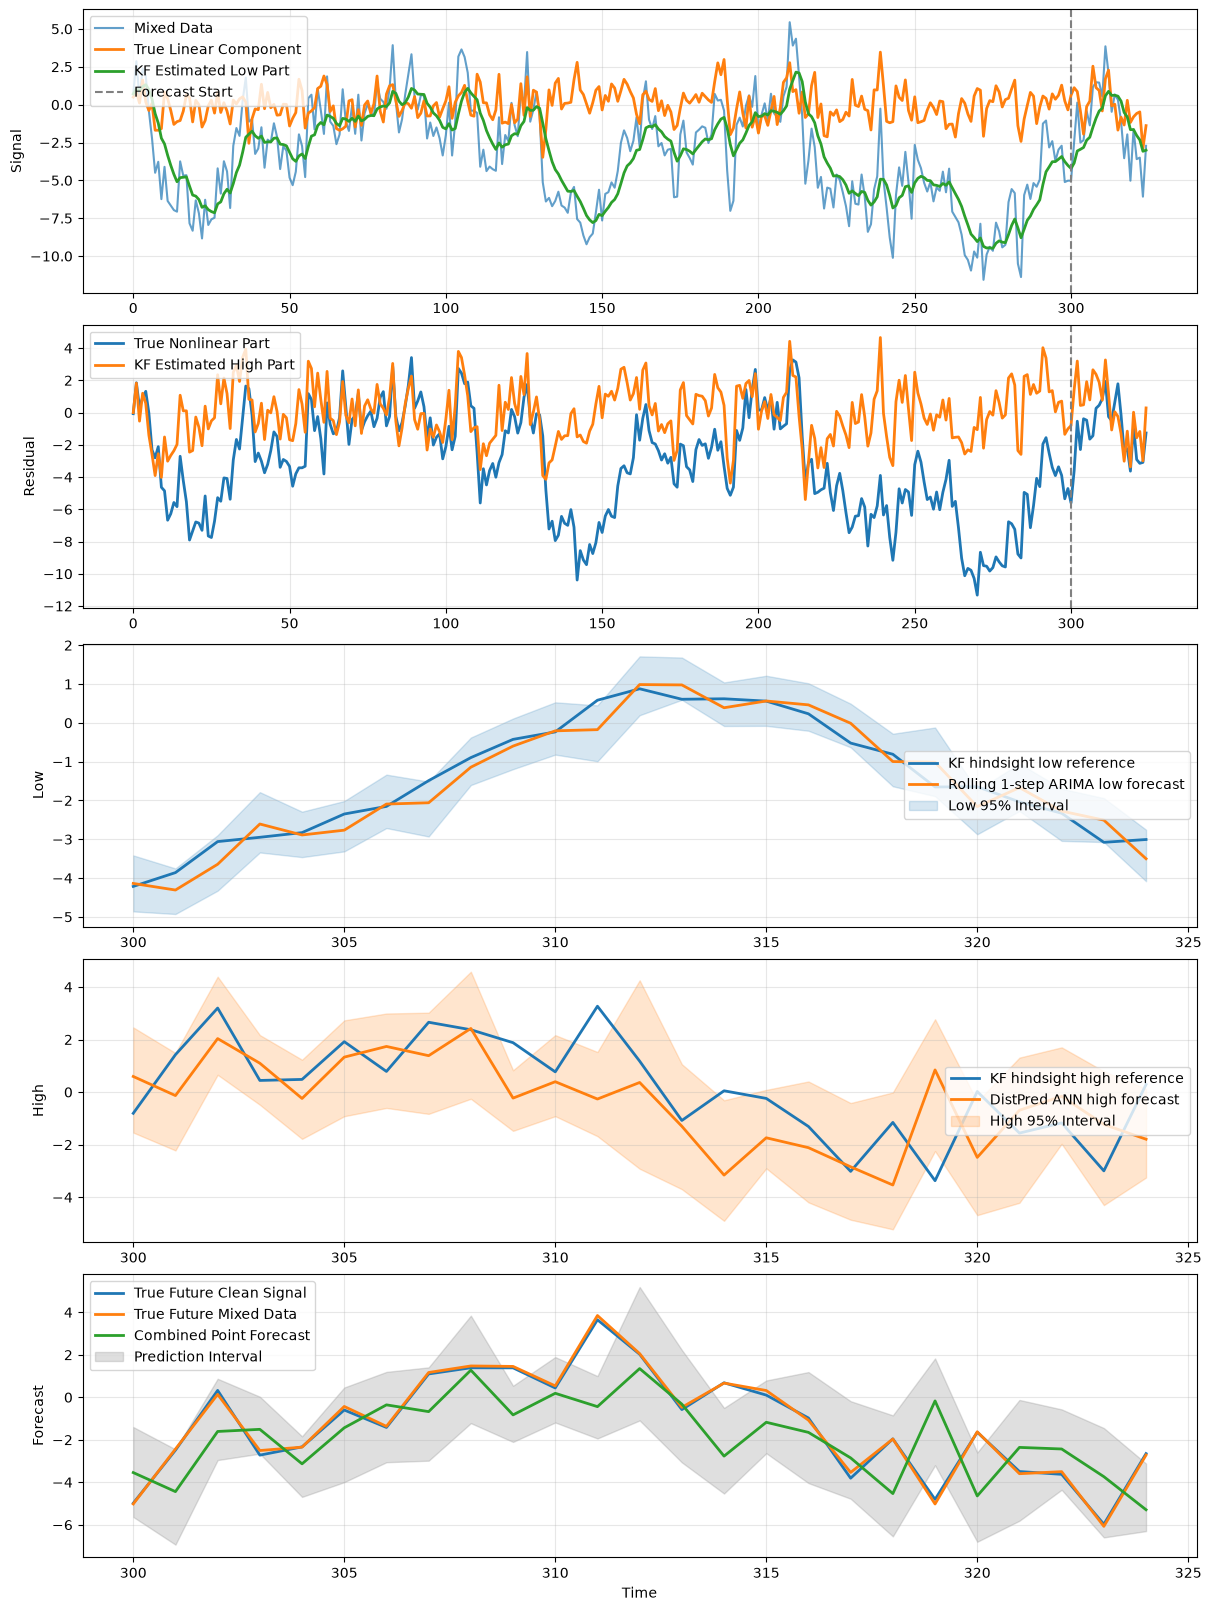

In [7]:
t = np.arange(len(result["measurements"]), dtype=float)
t_test = t[train_size:train_size + horizon]

fig, axes = plt.subplots(5, 1, figsize=(12, 16), constrained_layout=True)

axes[0].plot(t, result["measurements"], label="Mixed Data", alpha=0.7)
axes[0].plot(t, result["true_low_full"], label="True Linear Component", linewidth=2)
axes[0].plot(t, result["estimated_low_full"], label="KF Estimated Low Part", linewidth=2)
axes[0].axvline(t[train_size], color="gray", linestyle="--", label="Forecast Start")
axes[0].set_ylabel("Signal")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, result["true_high_full"], label="True Nonlinear Part", linewidth=2)
axes[1].plot(t, result["estimated_high_full"], label="KF Estimated High Part", linewidth=2)
axes[1].axvline(t[train_size], color="gray", linestyle="--")
axes[1].set_ylabel("Residual")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_test, result["reference_low_test"], label="KF hindsight low reference", linewidth=2)
axes[2].plot(t_test, result["low_forecast"], label="Rolling 1-step ARIMA low forecast", linewidth=2)
axes[2].fill_between(
    t_test,
    result["low_interval_lower"],
    result["low_interval_upper"],
    color="tab:blue",
    alpha=0.18,
    label="Low 95% Interval",
)
axes[2].set_ylabel("Low")
axes[2].legend(loc="center right")
axes[2].grid(True, alpha=0.3)

axes[3].plot(t_test, result["reference_high_test"], label="KF hindsight high reference", linewidth=2)
axes[3].plot(t_test, result["high_forecast"], label="DistPred ANN high forecast", linewidth=2)
axes[3].fill_between(
    t_test,
    result["high_interval_lower"],
    result["high_interval_upper"],
    color="tab:orange",
    alpha=0.20,
    label="High 95% Interval",
)
axes[3].set_ylabel("High")
axes[3].legend(loc="center right")
axes[3].grid(True, alpha=0.3)

axes[4].plot(t_test, result["true_clean_test"], label="True Future Clean Signal", linewidth=2)
axes[4].plot(t_test, result["measurements_test"], label="True Future Mixed Data", linewidth=2)
axes[4].plot(t_test, result["final_forecast"], label="Combined Point Forecast", linewidth=2)
axes[4].fill_between(
    t_test,
    result["interval_lower"],
    result["interval_upper"],
    color="gray",
    alpha=0.25,
    label="Prediction Interval",
)
axes[4].set_ylabel("Forecast")
axes[4].set_xlabel("Time")
axes[4].legend(loc="upper left")
axes[4].grid(True, alpha=0.3)

plt.show()
plt.close(fig)



## Monte Carlo 摘要實驗

這一段會重複執行多次實驗，彙整 MSE、coverage、interval width，以及 component correlation 的平均表現。

Mode                          : M1+M9 additive data with paper26-style Joint (L,H) DistPred
Monte Carlo runs               : 50
Observed sample sizes N        : [300, 500, 1000]
Forecast horizon h             : 50
Ensemble samples K             : 50
Rolling CV grid size           : 2

N | Train T | Mean low MSE | Mean high MSE | Mean noisy MSE | Mean noisy RMSE | Mean test std | Mean nRMSE | Mean noisy coverage | Mean interval width
--|---------|--------------|---------------|----------------|-----------------|---------------|------------|---------------------|--------------------
300 | 250      | 0.1396       | 2.5366        | 3.7887         | 1.9314          | 2.8643       | 0.6977     | 84.80%               | 6.1417
    Rolling CV selected params: window=9.82, epochs=100, lr=0.00050, folds=2.0
    Avg timing (s/run): data=0.00, point_fit=7.59
    Avg model breakdown (s/run): kf=0.00, high_ann=2.79
    Avg component interval: low_cov=90.92%, low_width=1.3455, high_cov=89.76%, high_wi

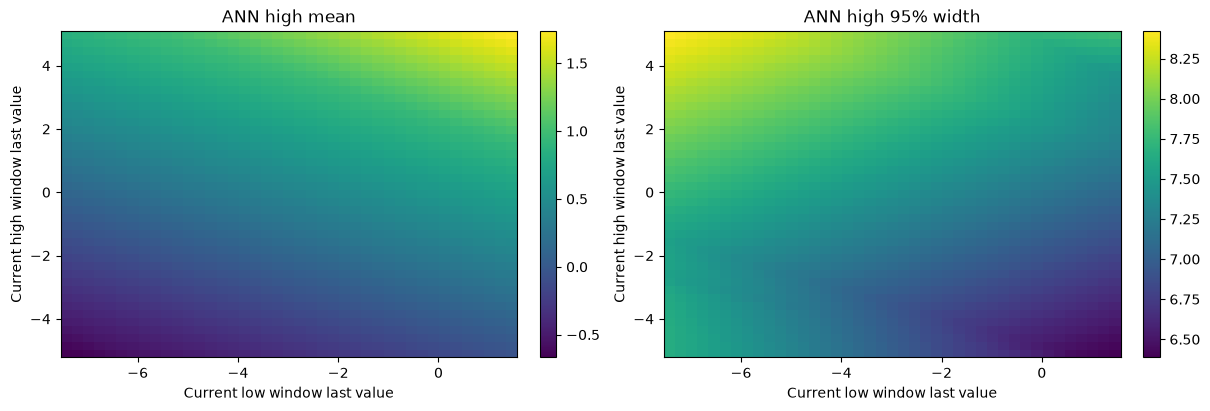

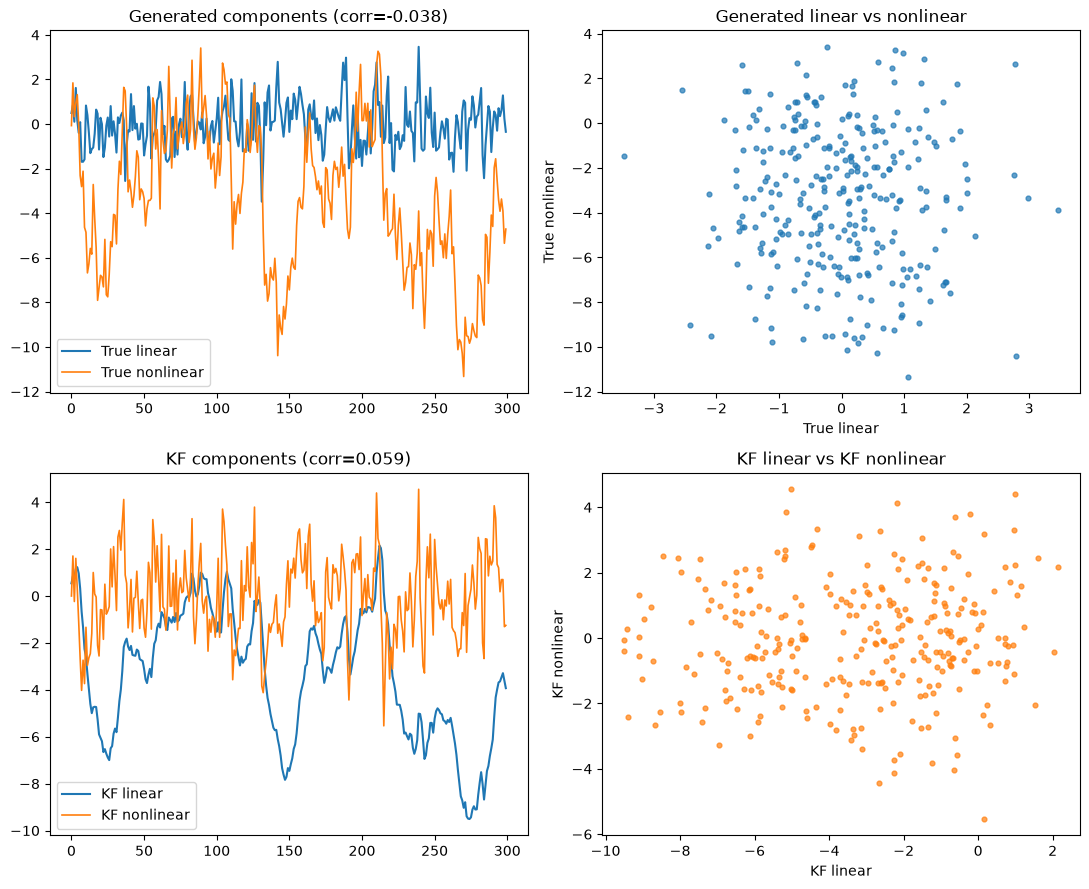

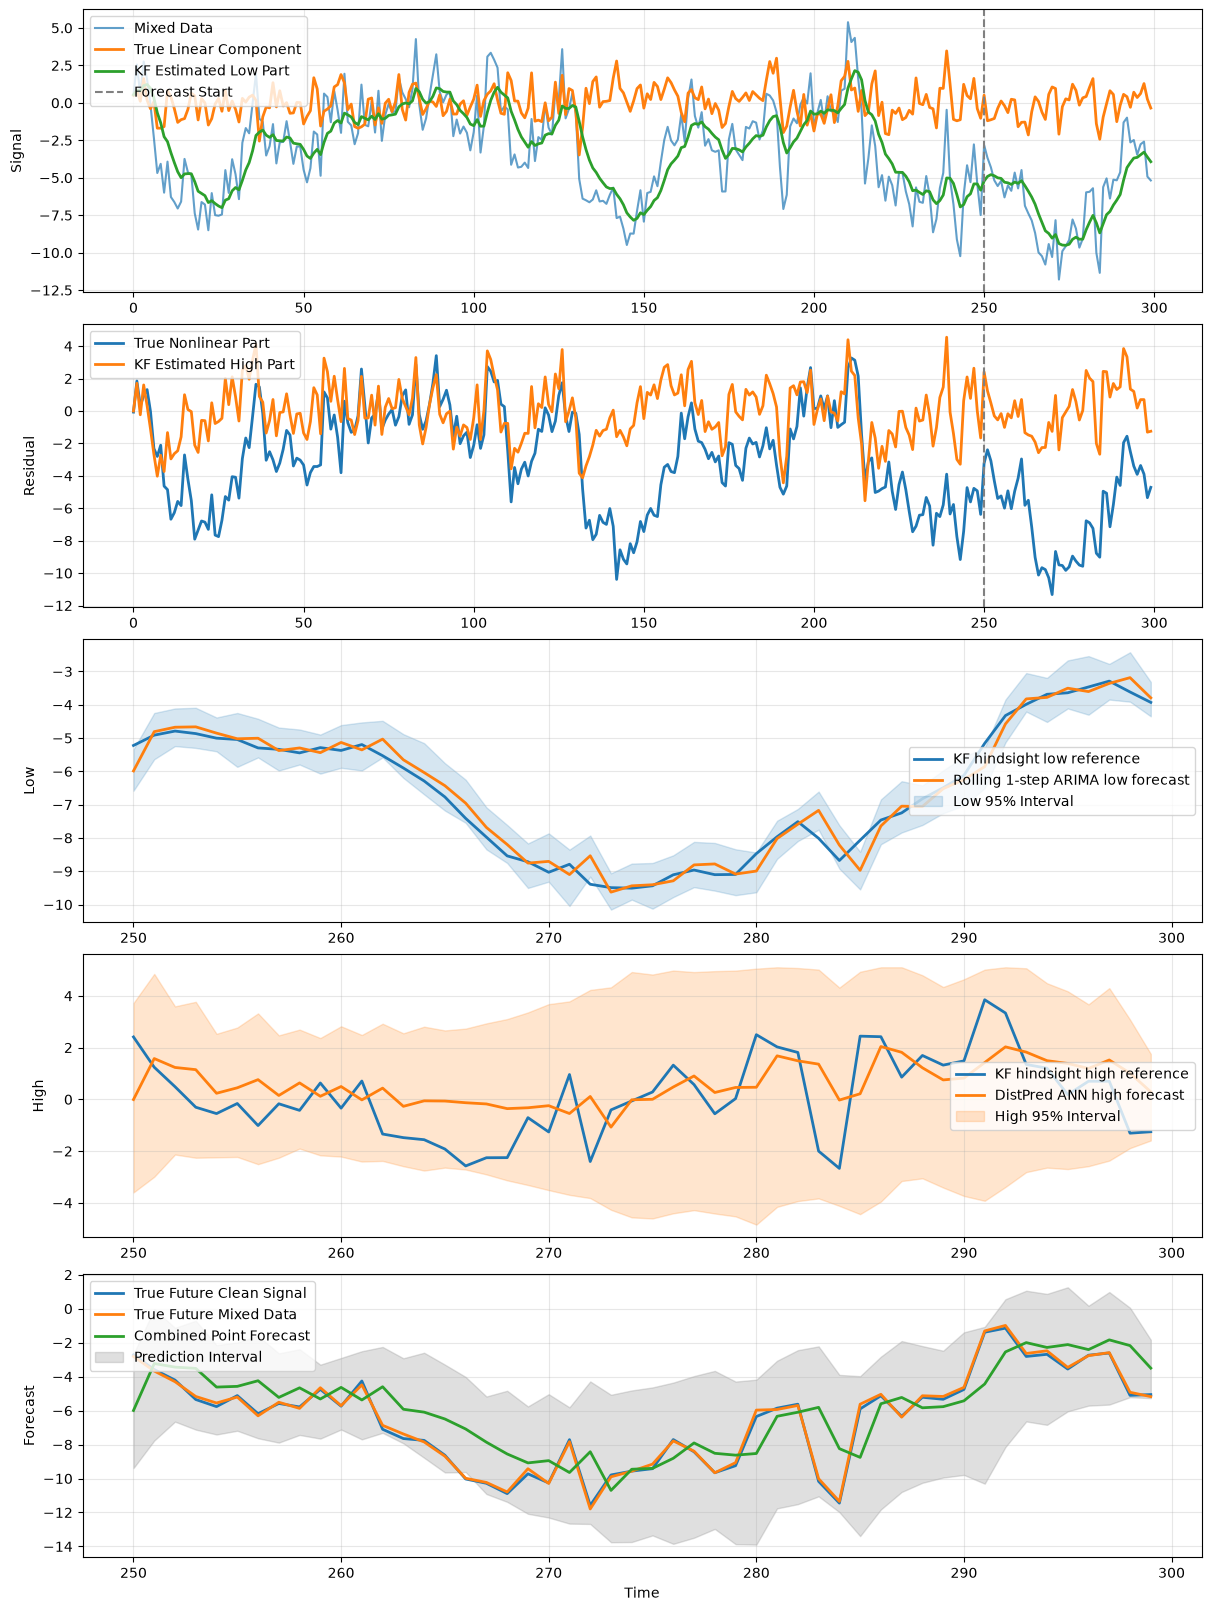

500 | 450      | 0.1375       | 2.2860        | 3.5110         | 1.8588          | 2.6976       | 0.7107     | 87.40%               | 6.0190
    Rolling CV selected params: window=8.42, epochs=100, lr=0.00050, folds=6.0
    Avg timing (s/run): data=0.00, point_fit=10.23
    Avg model breakdown (s/run): kf=0.00, high_ann=3.83
    Avg component interval: low_cov=91.84%, low_width=1.3459, high_cov=91.84%, high_width=5.8817, final_width=6.0190
    Avg component corr: generated=-0.0115 (R^2=0.0044), KF=0.0828 (R^2=0.0071)
    Component std independence check: MC std corr generated=0.0712, MC std corr KF=0.4871, avg rolling std corr generated=0.1637, avg rolling std corr KF=0.3195
    Representative plots for N=500, train T=450, h=50


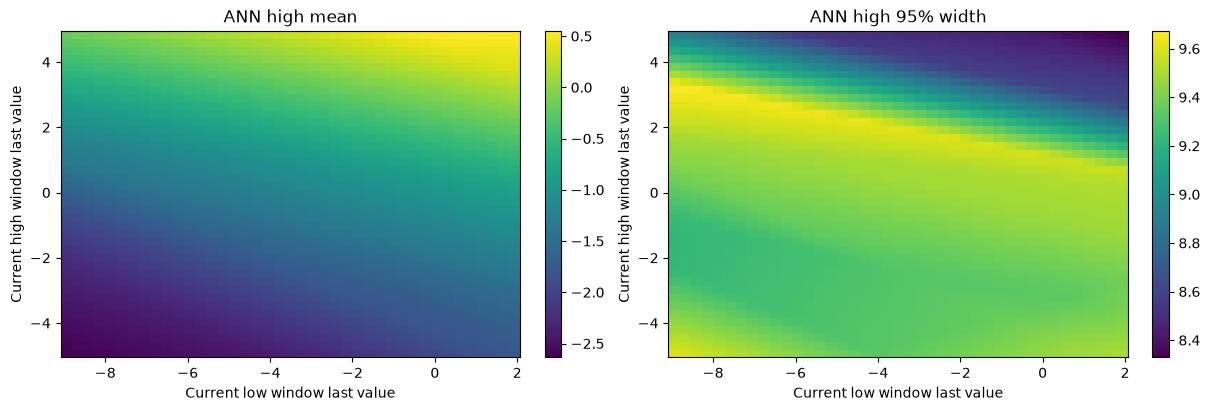

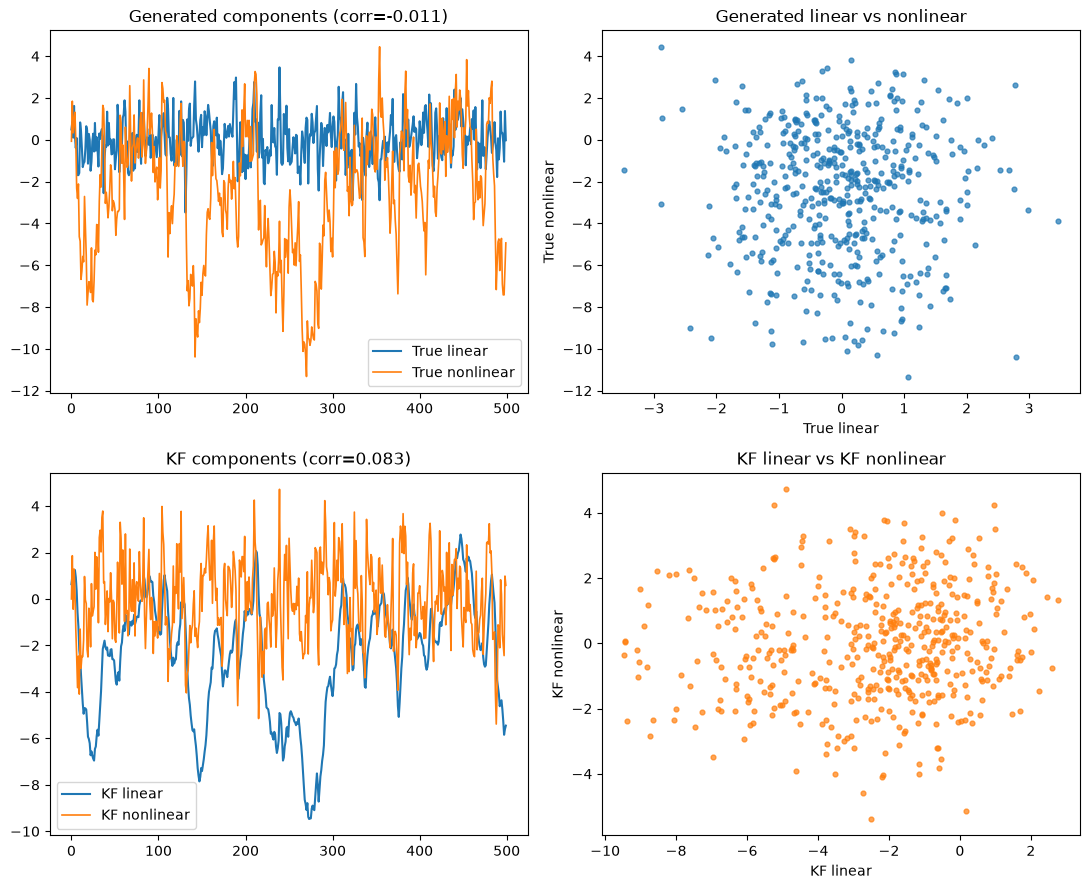

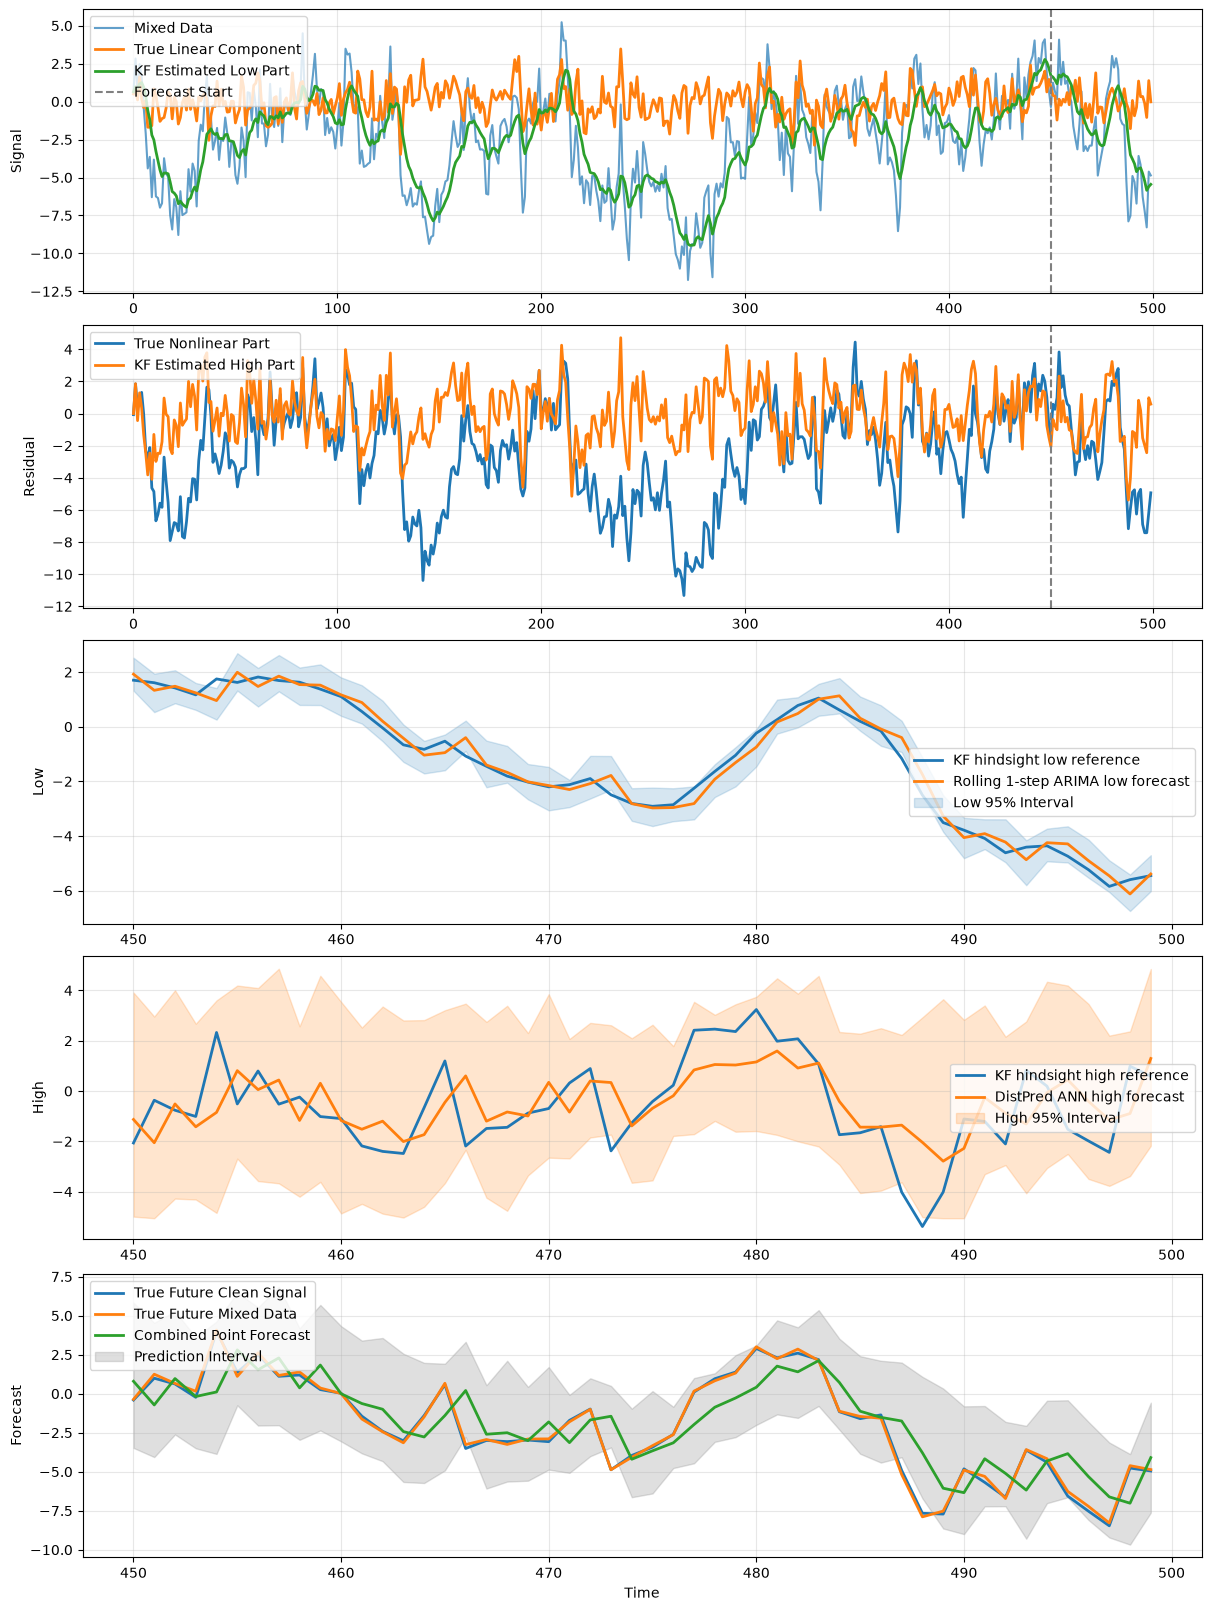

1000 | 950      | 0.1389       | 2.2889        | 3.5283         | 1.8637          | 2.9237       | 0.6739     | 87.20%               | 5.9911
    Rolling CV selected params: window=8.14, epochs=100, lr=0.00050, folds=16.0
    Avg timing (s/run): data=0.00, point_fit=16.53
    Avg model breakdown (s/run): kf=0.00, high_ann=6.49
    Avg component interval: low_cov=91.32%, low_width=1.3474, high_cov=92.80%, high_width=5.8233, final_width=5.9911
    Avg component corr: generated=-0.0097 (R^2=0.0026), KF=0.0820 (R^2=0.0069)
    Component std independence check: MC std corr generated=0.0965, MC std corr KF=0.3205, avg rolling std corr generated=0.1574, avg rolling std corr KF=0.3185
    Representative plots for N=1000, train T=950, h=50


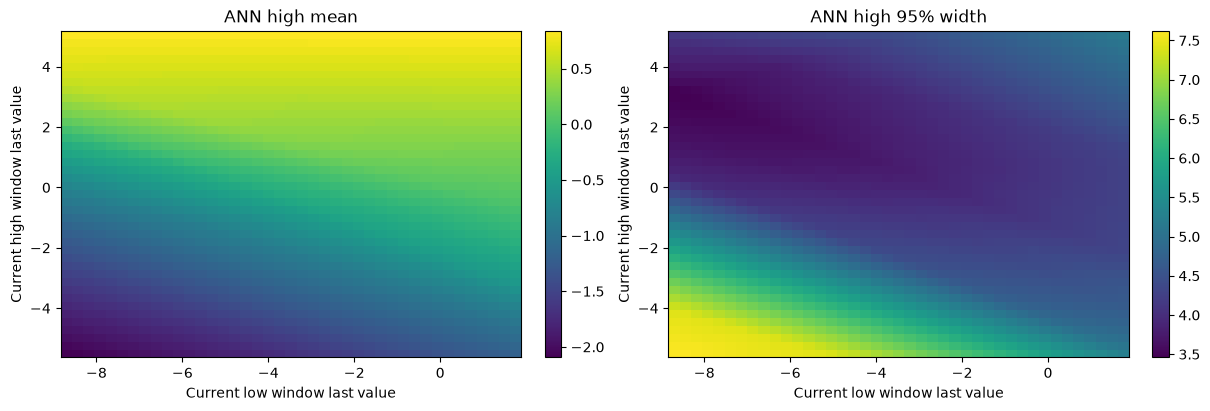

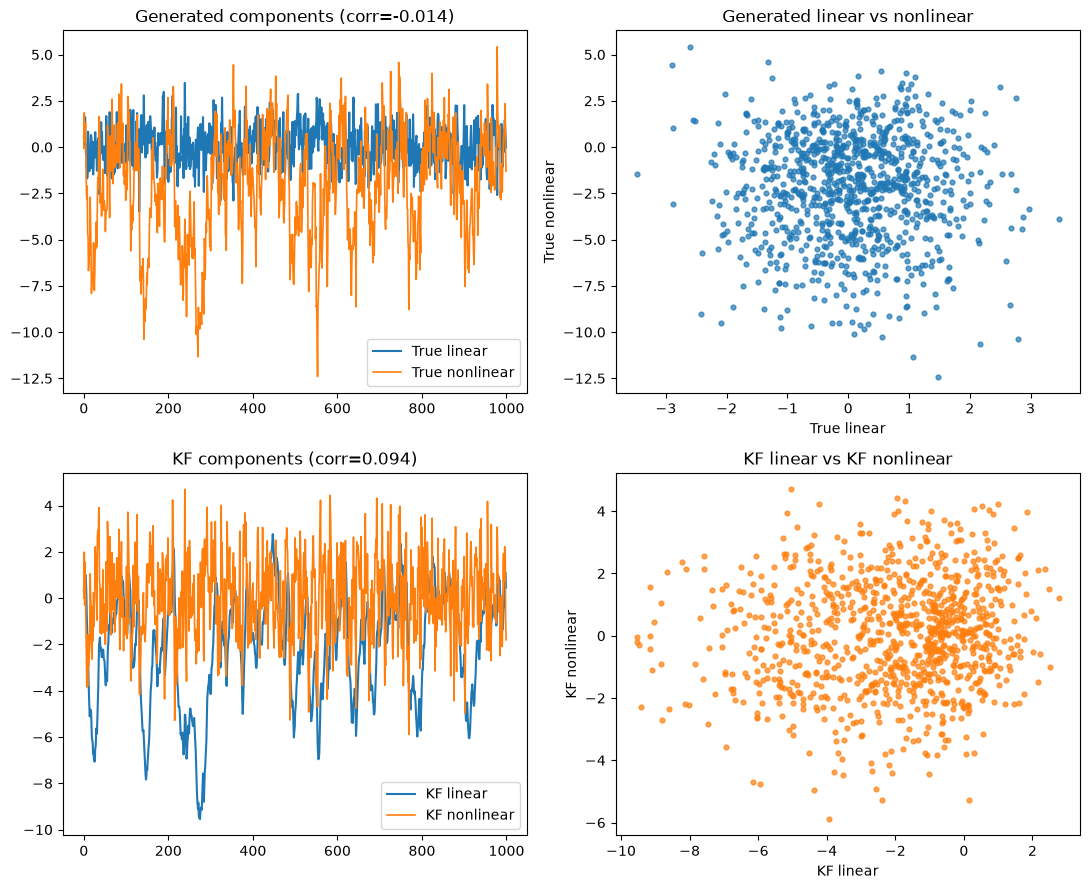

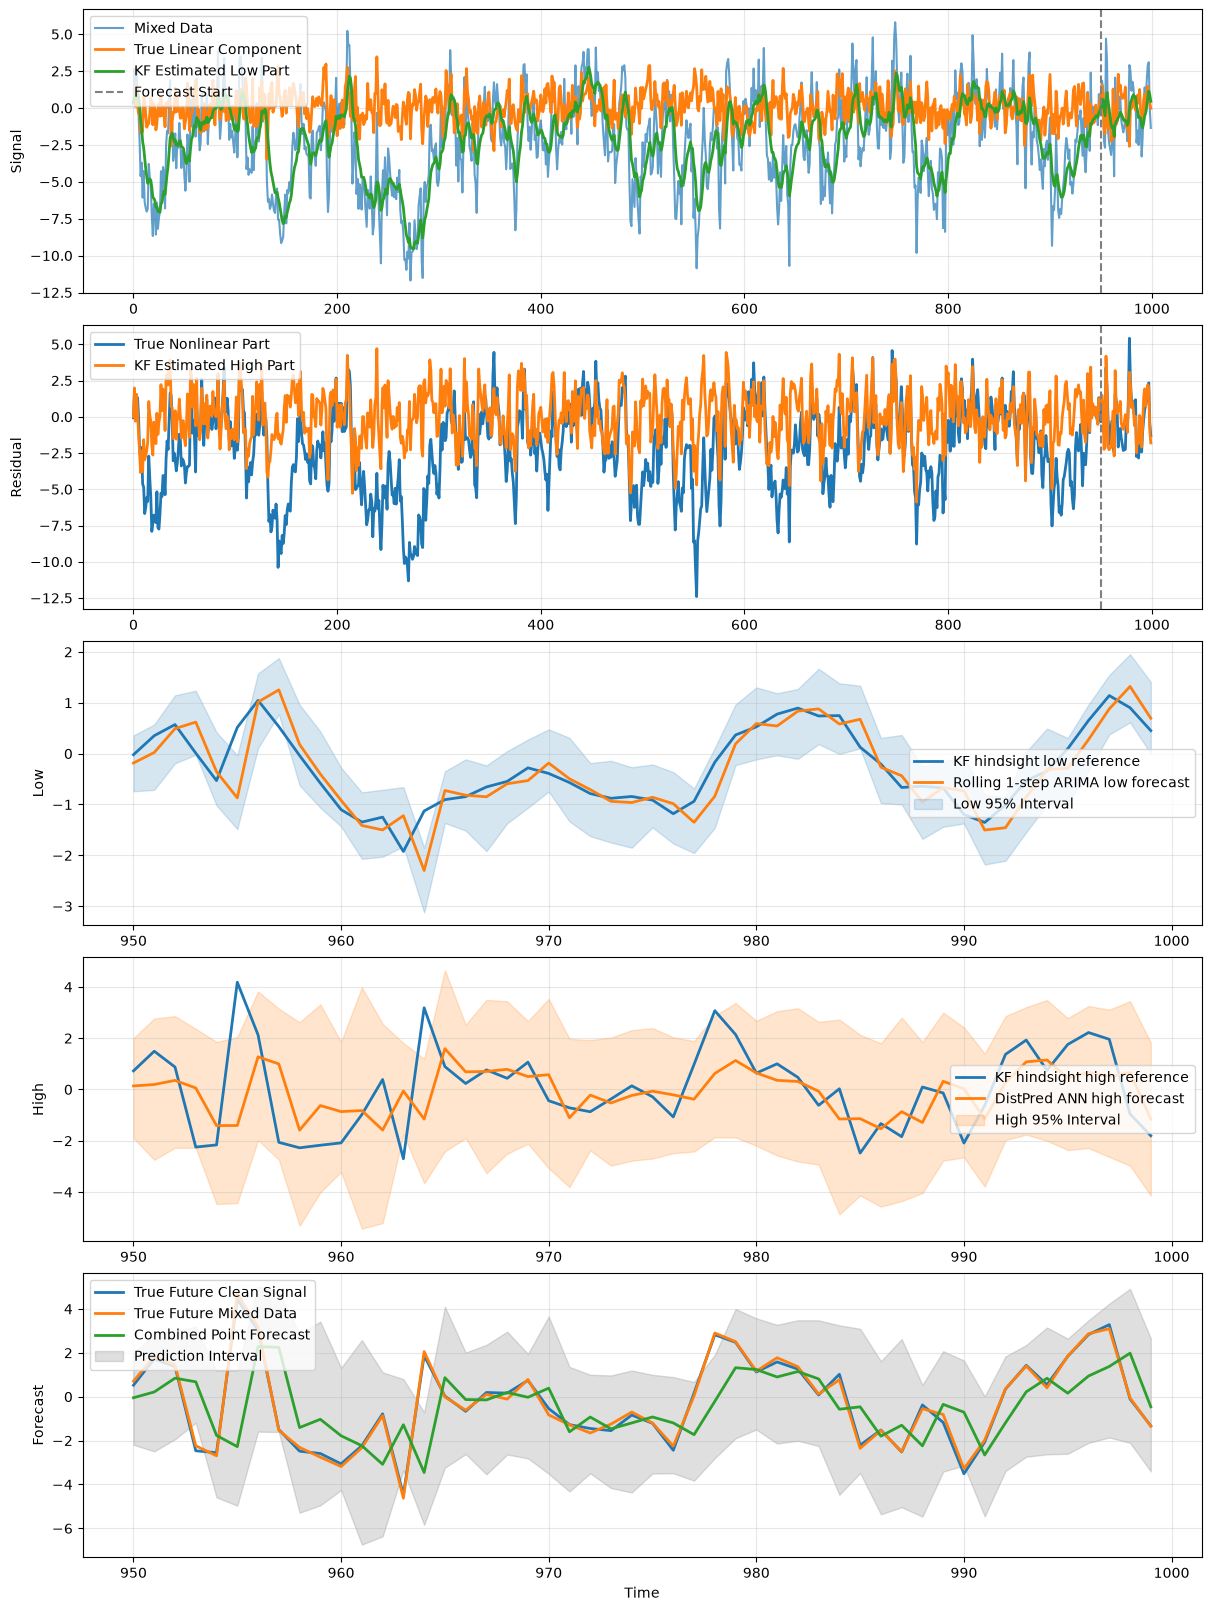


Elapsed time                   : 25480.58 seconds


In [ ]:
n_monte_carlo = 10
sample_sizes = [300, 500, 1000]
horizon = 50
ensemble_size = 50
param_grid = {
    "window_size": [8, 15],
    "epochs": [100],
    "learning_rate": [5e-4],
    "ensemble_size": [ensemble_size],
}

print("Mode                          : M1+M9 additive data with low ARIMA high ANN DistPred")
print(f"Monte Carlo runs               : {n_monte_carlo}")
print(f"Observed sample sizes N        : {sample_sizes}")
print(f"Forecast horizon h             : {horizon}")
print(f"Ensemble samples K             : {ensemble_size}")
print(f"Rolling CV grid size           : {np.prod([len(v) for v in param_grid.values()])}")
print("")
print("N | Train T | Mean low MSE | Mean high MSE | Mean noisy MSE | Mean noisy RMSE | Mean test std | Mean nRMSE | Mean noisy coverage | Mean interval width")
print("--|---------|--------------|---------------|----------------|-----------------|---------------|------------|---------------------|--------------------")

start_time = time.perf_counter()

for sample_size in sample_sizes:
    train_size = sample_size - horizon
    experiment_results = []
    for run_idx in range(n_monte_carlo):
        np.random.seed(42 + run_idx)
        torch.manual_seed(42 + run_idx)
        low_true, high_true, measurements = simulate_m1_m9_additive_data(sample_size)
        validation_sets, cv_results, best_params, top_cv_results = grid_search_high_ann_rolling_cv(
            measurements[:train_size],
            param_grid=param_grid,
            val_size=horizon,
            min_train_size=min(150, max(50, train_size - horizon)),
            step_size=horizon,
        )
        experiment_results.append(
            run_single_experiment(
                train_size=train_size,
                horizon=horizon,
                generated_data=(low_true, high_true, measurements),
                validation_summary={
                    "n_validation_folds": len(validation_sets),
                    "best_params": best_params,
                    "top_cv_results": top_cv_results,
                },
                **best_params,
            )
        )

    low_mses = np.array([result["low_mse"] for result in experiment_results], dtype=float)
    high_mses = np.array([result["high_mse"] for result in experiment_results], dtype=float)
    noisy_mses = np.array([result["final_noisy_mse"] for result in experiment_results], dtype=float)
    noisy_rmses = np.array([result["final_noisy_rmse"] for result in experiment_results], dtype=float)
    test_stds = np.array([result["test_std"] for result in experiment_results], dtype=float)
    normalized_rmses = np.array([result["normalized_rmse"] for result in experiment_results], dtype=float)
    noisy_coverages = np.array([result["noisy_coverage"] for result in experiment_results], dtype=float)
    low_component_coverages = np.array([result["low_component_coverage"] for result in experiment_results], dtype=float)
    high_component_coverages = np.array([result["high_component_coverage"] for result in experiment_results], dtype=float)
    mean_interval_widths = np.array([result["mean_interval_width"] for result in experiment_results], dtype=float)
    low_sample_widths = np.array([result["low_sample_width"] for result in experiment_results], dtype=float)
    high_sample_widths = np.array([result["high_sample_width"] for result in experiment_results], dtype=float)
    final_sample_widths = np.array([result["final_sample_width"] for result in experiment_results], dtype=float)
    true_component_corrs = np.array(
        [result["true_component_corr"]["pearson_corr"] for result in experiment_results],
        dtype=float,
    )
    kf_component_corrs = np.array(
        [result["kf_component_corr"]["pearson_corr"] for result in experiment_results],
        dtype=float,
    )
    true_component_corrsq = np.array(
        [result["true_component_corr"]["corr_sq"] for result in experiment_results],
        dtype=float,
    )
    kf_component_corrsq = np.array(
        [result["kf_component_corr"]["corr_sq"] for result in experiment_results],
        dtype=float,
    )
    true_low_stds = np.array([result["true_component_std"]["low_std"] for result in experiment_results], dtype=float)
    true_high_stds = np.array([result["true_component_std"]["high_std"] for result in experiment_results], dtype=float)
    kf_low_stds = np.array([result["kf_component_std"]["low_std"] for result in experiment_results], dtype=float)
    kf_high_stds = np.array([result["kf_component_std"]["high_std"] for result in experiment_results], dtype=float)
    true_std_corr = float(np.corrcoef(true_low_stds, true_high_stds)[0, 1])
    kf_std_corr = float(np.corrcoef(kf_low_stds, kf_high_stds)[0, 1])
    true_rolling_std_corrs = np.array(
        [result["true_rolling_std_corr"]["rolling_std_corr"] for result in experiment_results],
        dtype=float,
    )
    kf_rolling_std_corrs = np.array(
        [result["kf_rolling_std_corr"]["rolling_std_corr"] for result in experiment_results],
        dtype=float,
    )
    selected_window_sizes = np.array([result["window_size"] for result in experiment_results], dtype=float)
    selected_epochs = np.array([result["epochs"] for result in experiment_results], dtype=float)
    selected_learning_rates = np.array([result["learning_rate"] for result in experiment_results], dtype=float)
    validation_fold_counts = np.array([result["validation_summary"]["n_validation_folds"] for result in experiment_results], dtype=float)
    mean_data_generation = np.mean([result["timing_info"]["data_generation"] for result in experiment_results])
    mean_point_forecast_fit = np.mean([result["timing_info"]["point_forecast_fit"] for result in experiment_results])
    mean_kf_decomposition = np.mean([result["timing_info"]["kf_decomposition"] for result in experiment_results])
    mean_distpred_high_fit_forecast = np.mean(
        [result["timing_info"]["distpred_high_fit_forecast"] for result in experiment_results]
    )

    print(
        f"{sample_size} | "
        f"{train_size}      | "
        f"{np.mean(low_mses):.4f}       | "
        f"{np.mean(high_mses):.4f}        | "
        f"{np.mean(noisy_mses):.4f}         | "
        f"{np.mean(noisy_rmses):.4f}          | "
        f"{np.mean(test_stds):.4f}       | "
        f"{np.mean(normalized_rmses):.4f}     | "
        f"{np.mean(noisy_coverages):.2f}%               | "
        f"{np.mean(mean_interval_widths):.4f}"
    )
    print(
        "    Rolling CV selected params: "
        f"window={np.mean(selected_window_sizes):.2f}, "
        f"epochs={np.mean(selected_epochs):.0f}, "
        f"lr={np.mean(selected_learning_rates):.5f}, "
        f"folds={np.mean(validation_fold_counts):.1f}"
    )
    print(
        "    Avg timing (s/run): "
        f"data={mean_data_generation:.2f}, "
        f"point_fit={mean_point_forecast_fit:.2f}"
    )
    print(
        "    Avg model breakdown (s/run): "
        f"kf={mean_kf_decomposition:.2f}, "
        f"high_ann={mean_distpred_high_fit_forecast:.2f}"
    )
    print(
        "    Avg component interval: "
        f"low_cov={np.mean(low_component_coverages):.2f}%, "
        f"low_width={np.mean(low_sample_widths):.4f}, "
        f"high_cov={np.mean(high_component_coverages):.2f}%, "
        f"high_width={np.mean(high_sample_widths):.4f}, "
        f"final_width={np.mean(final_sample_widths):.4f}"
    )
    print(
        "    Avg component corr: "
        f"generated={np.mean(true_component_corrs):.4f} (R^2={np.mean(true_component_corrsq):.4f}), "
        f"KF={np.mean(kf_component_corrs):.4f} (R^2={np.mean(kf_component_corrsq):.4f})"
    )
    print(
        "    Component std independence check: "
        f"MC std corr generated={true_std_corr:.4f}, "
        f"MC std corr KF={kf_std_corr:.4f}, "
        f"avg rolling std corr generated={np.nanmean(true_rolling_std_corrs):.4f}, "
        f"avg rolling std corr KF={np.nanmean(kf_rolling_std_corrs):.4f}"
    )

    representative = experiment_results[0]
    print(f"    Representative plots for N={sample_size}, train T={train_size}, h={horizon}")
    plot_interaction(
        representative["joint_bundle"],
        representative["estimated_low_train"],
        representative["estimated_high_train"],
    )

    plot_component_correlation(
        representative["true_low_full"],
        representative["true_high_full"],
        representative["estimated_low_full"],
        representative["estimated_high_full"],
    )

    t = np.arange(len(representative["measurements"]), dtype=float)
    t_test = t[train_size:train_size + horizon]
    fig, axes = plt.subplots(5, 1, figsize=(12, 16), constrained_layout=True)

    axes[0].plot(t, representative["measurements"], label="Mixed Data", alpha=0.7)
    axes[0].plot(t, representative["true_low_full"], label="True Linear Component", linewidth=2)
    axes[0].plot(t, representative["estimated_low_full"], label="KF Estimated Low Part", linewidth=2)
    axes[0].axvline(t[train_size], color="gray", linestyle="--", label="Forecast Start")
    axes[0].set_ylabel("Signal")
    axes[0].legend(loc="upper left")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, representative["true_high_full"], label="True Nonlinear Part", linewidth=2)
    axes[1].plot(t, representative["estimated_high_full"], label="KF Estimated High Part", linewidth=2)
    axes[1].axvline(t[train_size], color="gray", linestyle="--")
    axes[1].set_ylabel("Residual")
    axes[1].legend(loc="upper left")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t_test, representative["reference_low_test"], label="KF hindsight low reference", linewidth=2)
    axes[2].plot(t_test, representative["low_forecast"], label="Rolling 1-step ARIMA low forecast", linewidth=2)
    axes[2].fill_between(
        t_test,
        representative["low_interval_lower"],
        representative["low_interval_upper"],
        color="tab:blue",
        alpha=0.18,
        label="Low 95% Interval",
    )
    axes[2].set_ylabel("Low")
    axes[2].legend(loc="center right")
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(t_test, representative["reference_high_test"], label="KF hindsight high reference", linewidth=2)
    axes[3].plot(t_test, representative["high_forecast"], label="DistPred ANN high forecast", linewidth=2)
    axes[3].fill_between(
        t_test,
        representative["high_interval_lower"],
        representative["high_interval_upper"],
        color="tab:orange",
        alpha=0.20,
        label="High 95% Interval",
    )
    axes[3].set_ylabel("High")
    axes[3].legend(loc="center right")
    axes[3].grid(True, alpha=0.3)

    axes[4].plot(t_test, representative["true_clean_test"], label="True Future Clean Signal", linewidth=2)
    axes[4].plot(t_test, representative["measurements_test"], label="True Future Mixed Data", linewidth=2)
    axes[4].plot(t_test, representative["final_forecast"], label="Combined Point Forecast", linewidth=2)
    axes[4].fill_between(
        t_test,
        representative["interval_lower"],
        representative["interval_upper"],
        color="gray",
        alpha=0.25,
        label="Prediction Interval",
    )
    axes[4].set_ylabel("Forecast")
    axes[4].set_xlabel("Time")
    axes[4].legend(loc="upper left")
    axes[4].grid(True, alpha=0.3)

    plt.show()
    plt.close(fig)

elapsed_time = time.perf_counter() - start_time
print("")
print(f"Elapsed time                   : {elapsed_time:.2f} seconds")
